In [1]:
#Data Cleaning & Feature Engineering

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


print("Loading cleaned data...")
try:
    df = pd.read_csv('telco_churn_cleaned.csv')
    print(f"Data loaded! Shape: {df.shape}")
except:
    print("Couldn't find cleaned data, loading fresh...")
    url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
    df = pd.read_csv(url)
    
    # Basic cleaning ,for that total charge imbalanced data
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    zero_tenure_mask = df['tenure'] == 0
    nan_mask = df['TotalCharges'].isna()
    df.loc[zero_tenure_mask & nan_mask, 'TotalCharges'] = 0
    median_charges = df['TotalCharges'].median()
    df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = median_charges

print(f"\nInitial data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Libraries imported successfully!
Loading cleaned data...
Data loaded! Shape: (7043, 22)

Initial data shape: (7043, 22)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_numeric']


In [2]:
print("DATA QUALITY AUDIT")

def audit_data_quality(df):
    """Perform comprehensive data quality check"""
    
    print("\nData Quality Report:")
    print("-" * 40)
    
    # 1. Missing values
    print("\n  Missing Values Analysis:")
    missing_data = df.isnull().sum()
    missing_percentage = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Count': missing_data,
        'Percentage': missing_percentage
    })
    
    missing_df = missing_df[missing_df['Missing Count'] > 0]
    
    if len(missing_df) > 0:
        print("Found missing values:")
        print(missing_df)
    else:
        print("No missing values found!")
    
    # 2. Duplicates
    print("\nDuplicate Records:")
    duplicates = df.duplicated().sum()
    print(f"   Total duplicate rows: {duplicates}")
    if duplicates > 0:
        print(f"Removing {duplicates} duplicate rows...")
        df = df.drop_duplicates()
    else:
        print("No duplicate rows found!")
    
    # 3. Data types check
    print("\nData Types Analysis:")
    dtypes_df = pd.DataFrame(df.dtypes, columns=['Data Type'])
    dtypes_df['Count'] = 1
    dtype_summary = dtypes_df.groupby('Data Type').count()
    print(dtype_summary)
    
    # 4. Unique values per column
    print("\nUnique Values per Column:")
    unique_counts = {}
    for col in df.columns:
        unique_counts[col] = df[col].nunique()
    
    unique_df = pd.DataFrame.from_dict(unique_counts, orient='index', 
                                       columns=['Unique Values'])
    unique_df = unique_df.sort_values('Unique Values', ascending=False)
    print(unique_df.head(10))  # Show top 10
    
    # 5. Zero/blank values in important columns
    print("\nZero/Blank Values in Key Columns:")
    key_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
    for col in key_columns:
        if col in df.columns:
            zeros = (df[col] == 0).sum()
            if pd.api.types.is_numeric_dtype(df[col]):
                blanks = df[col].isna().sum()
                print(f"   {col}: {zeros} zeros, {blanks} blanks")
    
    return df

df = audit_data_quality(df)
print(f"\nData shape after audit: {df.shape}")

DATA QUALITY AUDIT

Data Quality Report:
----------------------------------------

  Missing Values Analysis:
No missing values found!

Duplicate Records:
   Total duplicate rows: 0
No duplicate rows found!

Data Types Analysis:
           Count
Data Type       
int64          3
float64        2
object        17

Unique Values per Column:
                  Unique Values
customerID                 7043
TotalCharges               6531
MonthlyCharges             1585
tenure                       73
PaymentMethod                 4
MultipleLines                 3
Contract                      3
StreamingTV                   3
DeviceProtection              3
StreamingMovies               3

Zero/Blank Values in Key Columns:
   tenure: 11 zeros, 0 blanks
   MonthlyCharges: 0 zeros, 0 blanks
   TotalCharges: 11 zeros, 0 blanks

Data shape after audit: (7043, 22)


CATEGORICAL VARIABLE ANALYSIS

 Found 15 categorical columns:
          Column  Unique Values                                                                                    Values
          gender              2                                                                           'Female' 'Male'
         Partner              2                                                                                'Yes' 'No'
      Dependents              2                                                                                'No' 'Yes'
    PhoneService              2                                                                                'No' 'Yes'
   MultipleLines              3                                                             'No phone service' 'No' 'Yes'
 InternetService              3                                                                  'DSL' 'Fiber optic' 'No'
  OnlineSecurity              3                                                     

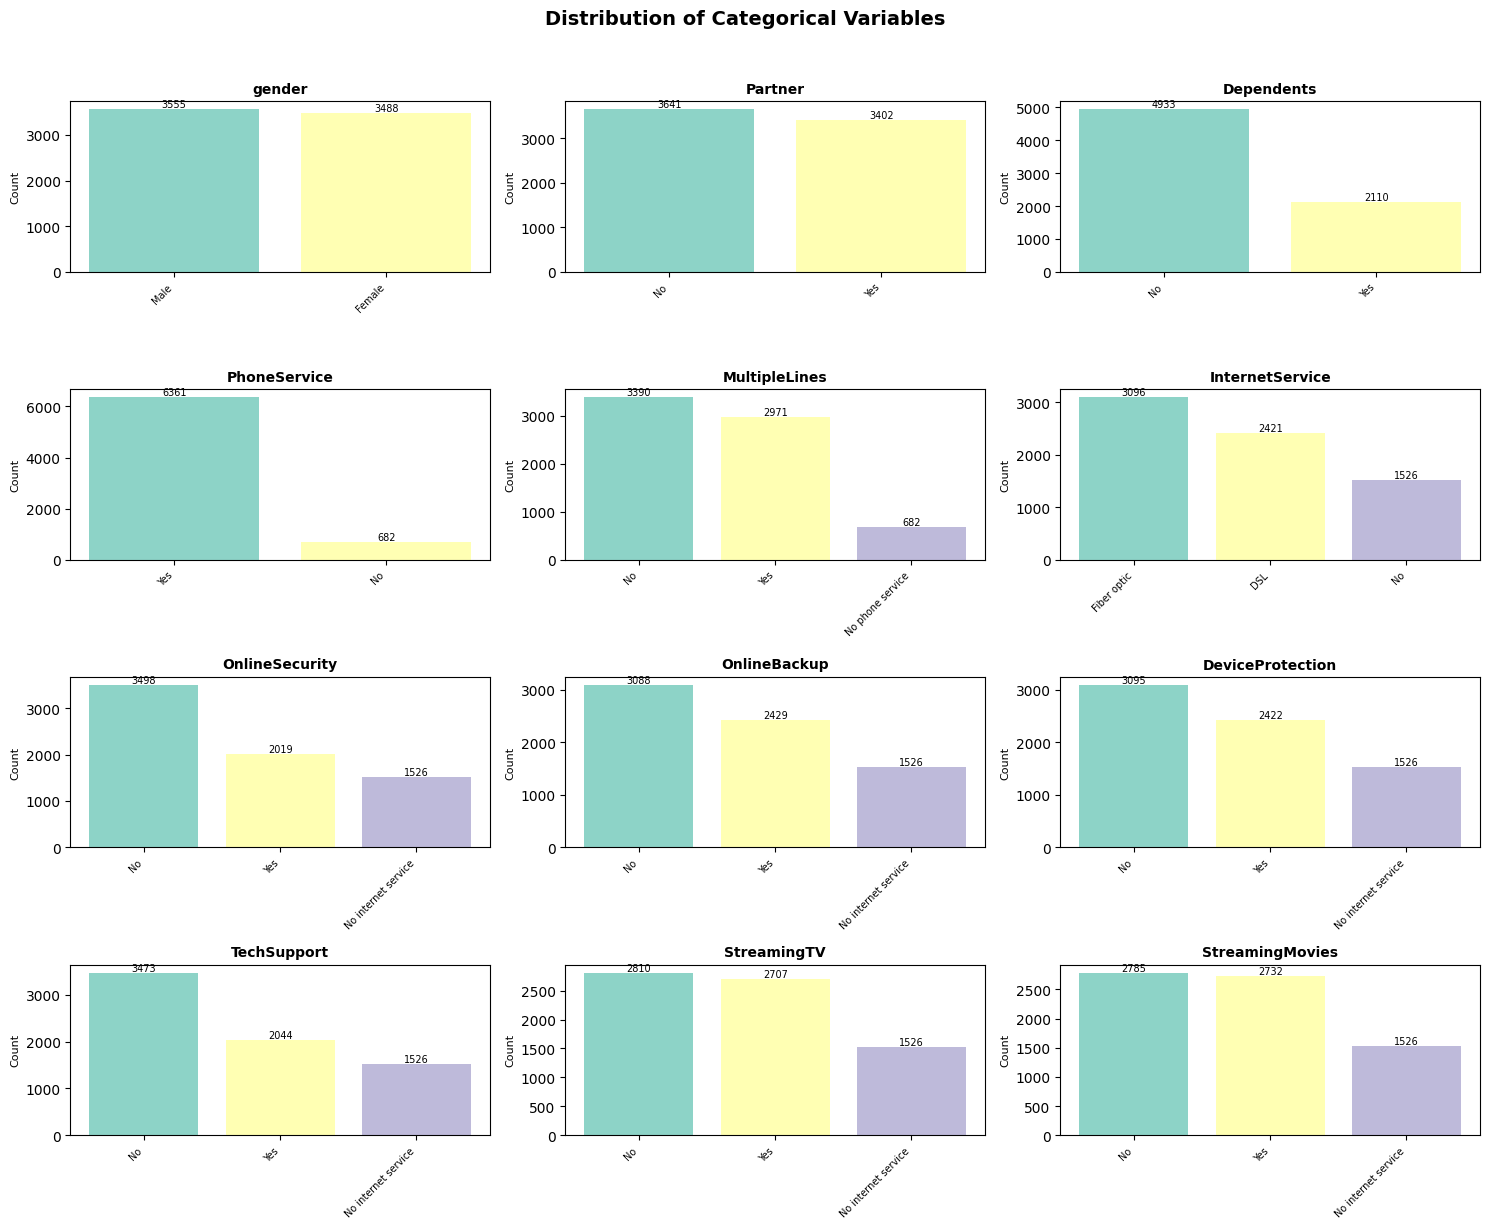

In [3]:
print("CATEGORICAL VARIABLE ANALYSIS")

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')  # We'll handle target separately

print(f"\n Found {len(categorical_cols)} categorical columns:")

# Create a summary table for categorical variables
cat_summary = []
for col in categorical_cols:
    unique_vals = df[col].unique()
    num_unique = len(unique_vals)
    cat_summary.append({
        'Column': col,
        'Unique Values': num_unique,
        'Values': str(unique_vals[:5])[1:-1] + ('...' if num_unique > 5 else '')
    })

cat_df = pd.DataFrame(cat_summary)
print(cat_df.to_string(index=False))

# Visualize distribution of categorical variables
print("\n Visualizing categorical distributions...")
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:12]):  # First 12 columns
    ax = axes[idx]
    
    # Get value counts
    value_counts = df[col].value_counts().head(10)  # Top 10 values
    
    # Create bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values, 
                  color=plt.cm.Set3(range(len(value_counts))))
    
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=8)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=7)
    
    # Add count labels
    for i, v in enumerate(value_counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=7)

# Hide unused subplots
for idx in range(len(categorical_cols[:12]), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribution of Categorical Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
print("FEATURE ENGINEERING")


print("\n🔧 Creating new features from existing data...")

# Create a copy for feature engineering
df_features = df.copy()

# 1. Customer Value Features
print("\nCustomer Value Features:")

# Monthly charge per service (estimate)
df_features['AvgChargePerMonth'] = df_features['TotalCharges'] / (df_features['tenure'] + 1)

# Charge ratio
df_features['MonthlyToTotalRatio'] = df_features['MonthlyCharges'] / (df_features['TotalCharges'] + 1)

# Customer lifetime value estimate
df_features['EstimatedLifetimeValue'] = df_features['MonthlyCharges'] * 12 * 3  # 3 years projection

print(f"   Created: AvgChargePerMonth, MonthlyToTotalRatio, EstimatedLifetimeValue")

# 2. Service Count Features
print("\nService Count Features:")

# List of service columns
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

# Convert services to binary (Yes=1, No/No service=0)
for col in service_cols:
    if col in df_features.columns:
        df_features[f'{col}_binary'] = df_features[col].apply(
            lambda x: 1 if x in ['Yes', 'DSL', 'Fiber optic'] else 0
        )

# Total number of services
binary_cols = [col for col in df_features.columns if '_binary' in col]
df_features['TotalServices'] = df_features[binary_cols].sum(axis=1)

# Premium services count (streaming, security, etc)
premium_services = ['OnlineSecurity_binary', 'OnlineBackup_binary', 
                    'DeviceProtection_binary', 'TechSupport_binary',
                    'StreamingTV_binary', 'StreamingMovies_binary']
df_features['PremiumServices'] = df_features[premium_services].sum(axis=1)

print(f"   Created: TotalServices ({df_features['TotalServices'].mean():.1f} avg)")
print(f"   Created: PremiumServices ({df_features['PremiumServices'].mean():.1f} avg)")

# 3. Behavioral Features
print("\nBehavioral Features:")

# Tenure groups
def categorize_tenure(months):
    if months == 0:
        return 'New'
    elif months <= 12:
        return 'Short-term'
    elif months <= 36:
        return 'Mid-term'
    else:
        return 'Long-term'

df_features['TenureGroup'] = df_features['tenure'].apply(categorize_tenure)

# Monthly charge groups
df_features['ChargeGroup'] = pd.qcut(df_features['MonthlyCharges'], 
                                     q=4, 
                                     labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# Contract risk score (higher for month-to-month)
contract_risk = {'Month-to-month': 3, 'One year': 2, 'Two year': 1}
df_features['ContractRisk'] = df_features['Contract'].map(contract_risk)

# Payment risk score
payment_risk = {'Electronic check': 3, 'Mailed check': 2, 
                'Bank transfer (automatic)': 1, 'Credit card (automatic)': 1}
df_features['PaymentRisk'] = df_features['PaymentMethod'].map(payment_risk)

print(f"   Created: TenureGroup, ChargeGroup, ContractRisk, PaymentRisk")

# 4. Interaction Features
print("\nInteraction Features:")

# Service charge efficiency
df_features['ChargePerService'] = df_features['MonthlyCharges'] / (df_features['TotalServices'] + 1)

# Tenure to charge ratio
df_features['TenureChargeRatio'] = df_features['tenure'] / (df_features['MonthlyCharges'] + 1)

# Senior citizen with dependents
df_features['SeniorWithDependents'] = ((df_features['SeniorCitizen'] == 1) & 
                                       (df_features['Dependents'] == 'Yes')).astype(int)

print(f"   Created: ChargePerService, TenureChargeRatio, SeniorWithDependents")

# 5. Risk Score (Composite Feature)
print("\nComposite Risk Score:")
df_features['RiskScore'] = (
    df_features['ContractRisk'] * 0.3 +
    df_features['PaymentRisk'] * 0.2 +
    (df_features['MonthlyCharges'] > df_features['MonthlyCharges'].median()).astype(int) * 0.2 +
    (df_features['tenure'] < 12).astype(int) * 0.3
)

print(f"   Created: RiskScore (0-1 scale)")
print(f"   RiskScore stats: Mean={df_features['RiskScore'].mean():.2f}, "
      f"Std={df_features['RiskScore'].std():.2f}")

print(f"\nTotal new features created: {len(df_features.columns) - len(df.columns)}")
print(f"New data shape: {df_features.shape}")

FEATURE ENGINEERING

🔧 Creating new features from existing data...

Customer Value Features:
   Created: AvgChargePerMonth, MonthlyToTotalRatio, EstimatedLifetimeValue

Service Count Features:
   Created: TotalServices (3.4 avg)
   Created: PremiumServices (2.0 avg)

Behavioral Features:
   Created: TenureGroup, ChargeGroup, ContractRisk, PaymentRisk

Interaction Features:
   Created: ChargePerService, TenureChargeRatio, SeniorWithDependents

Composite Risk Score:
   Created: RiskScore (0-1 scale)
   RiskScore stats: Mean=1.26, Std=0.45

Total new features created: 21
New data shape: (7043, 43)


VISUALIZING NEW FEATURES


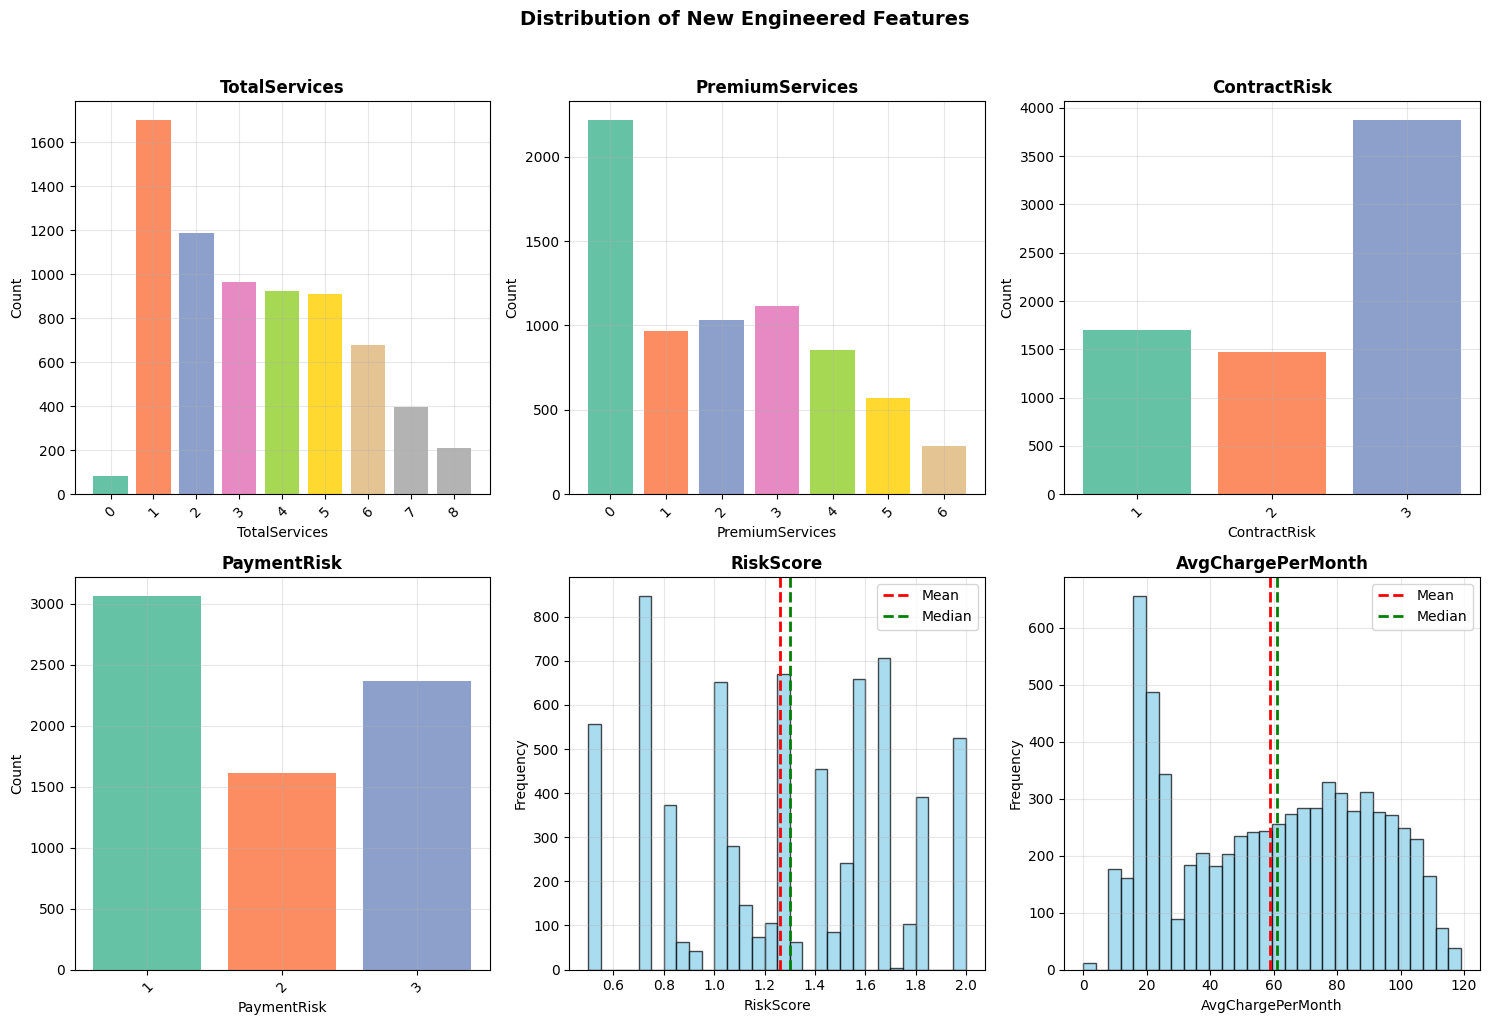


Correlation of New Features with Churn:

Top correlations with churn:
   RiskScore           :   0.473 (positive correlation)
   ContractRisk        :   0.397 (positive correlation)
   PaymentRisk         :   0.283 (positive correlation)
   PremiumServices     :  -0.088 (negative correlation)
   AvgChargePerMonth   :   0.073 (positive correlation)
   TotalServices       :  -0.067 (negative correlation)


In [6]:
print("VISUALIZING NEW FEATURES")

# Select some of the new features to visualize
new_features = ['TotalServices', 'PremiumServices', 'ContractRisk', 
                'PaymentRisk', 'RiskScore', 'AvgChargePerMonth']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(new_features[:6]):
    ax = axes[idx]
    
    if feature in df_features.columns:
        # Create subplot based on feature type
        if df_features[feature].nunique() <= 10:  # Categorical-like
            # Plot distribution
            value_counts = df_features[feature].value_counts().sort_index()
            bars = ax.bar(range(len(value_counts)), value_counts.values,
                         color=plt.cm.Set2(range(len(value_counts))))
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels([str(x) for x in value_counts.index], rotation=45)
            ax.set_ylabel('Count')
            
        else:  # Continuous
            # Plot histogram
            ax.hist(df_features[feature], bins=30, alpha=0.7, 
                   color='skyblue', edgecolor='black')
            ax.axvline(df_features[feature].mean(), color='red', 
                      linestyle='--', linewidth=2, label='Mean')
            ax.axvline(df_features[feature].median(), color='green', 
                      linestyle='--', linewidth=2, label='Median')
            ax.legend()
            ax.set_ylabel('Frequency')
        
        ax.set_title(feature, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(feature)

plt.suptitle('Distribution of New Engineered Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('new_features_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Show correlation of new features with churn
print("\nCorrelation of New Features with Churn:")

# Create numeric churn column
df_features['Churn_numeric'] = df_features['Churn'].map({'Yes': 1, 'No': 0})

# Calculate correlation for new features
new_feature_corr = {}
for feature in new_features:
    if feature in df_features.columns:
        corr = df_features[[feature, 'Churn_numeric']].corr().iloc[0, 1]
        new_feature_corr[feature] = corr

# Sort by absolute correlation
sorted_corr = sorted(new_feature_corr.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nTop correlations with churn:")
for feature, corr in sorted_corr:
    direction = "positive" if corr > 0 else "negative"
    print(f"   {feature:20s}: {corr:7.3f} ({direction} correlation)")

In [7]:
print("ENCODING CATEGORICAL VARIABLES")


from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print("\n Preparing categorical variables for machine learning...")


df_encoded = df_features.copy()

print("\nLabel Encoding (for binary variables):")
label_encoder = LabelEncoder()

binary_categorical = []
for col in categorical_cols:
    if df_encoded[col].nunique() == 2:
        binary_categorical.append(col)

print(f"   Found {len(binary_categorical)} binary categorical variables:")
for col in binary_categorical:
    original_vals = df_encoded[col].unique()
    df_encoded[f'{col}_encoded'] = label_encoder.fit_transform(df_encoded[col])
    print(f"   - {col}: {original_vals} → [0, 1]")

# 2. One-Hot Encoding for multi-class categorical variables
print("\nOne-Hot Encoding (for multi-class variables):")
multi_categorical = [col for col in categorical_cols if col not in binary_categorical]

# We'll handle these in the pipeline, but let's see what we have
print(f"Found {len(multi_categorical)} multi-class categorical variables:")
for col in multi_categorical[:5]:  # Show first 5
    unique_vals = df_encoded[col].unique()
    print(f"   - {col}: {len(unique_vals)} unique values")
    if len(unique_vals) <= 5:
        print(f"     Values: {unique_vals}")

if len(multi_categorical) > 5:
    print(f"   ... and {len(multi_categorical) - 5} more")

# 3. Manual encoding for important ordinal variables
print("\nManual Encoding (for ordinal variables):")

# InternetService: No < DSL < Fiber optic
internet_mapping = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
df_encoded['InternetService_encoded'] = df_encoded['InternetService'].map(internet_mapping)

# Contract: Two year < One year < Month-to-month (reverse for risk)
contract_mapping = {'Two year': 0, 'One year': 1, 'Month-to-month': 2}
df_encoded['Contract_encoded'] = df_encoded['Contract'].map(contract_mapping)

print(f"   Created encoded versions for InternetService and Contract")

# 4. Target variable encoding
print("\nTarget Variable Encoding:")
df_encoded['Churn_encoded'] = label_encoder.fit_transform(df_encoded['Churn'])
print(f"   Churn: {df_encoded['Churn'].unique()} → {df_encoded['Churn_encoded'].unique()}")

print(f"\nEncoding complete!")
print(f"Encoded data shape: {df_encoded.shape}")
print(f" Total columns after encoding: {len(df_encoded.columns)}")

ENCODING CATEGORICAL VARIABLES

 Preparing categorical variables for machine learning...

Label Encoding (for binary variables):
   Found 5 binary categorical variables:
   - gender: ['Female' 'Male'] → [0, 1]
   - Partner: ['Yes' 'No'] → [0, 1]
   - Dependents: ['No' 'Yes'] → [0, 1]
   - PhoneService: ['No' 'Yes'] → [0, 1]
   - PaperlessBilling: ['Yes' 'No'] → [0, 1]

One-Hot Encoding (for multi-class variables):
Found 10 multi-class categorical variables:
   - MultipleLines: 3 unique values
     Values: ['No phone service' 'No' 'Yes']
   - InternetService: 3 unique values
     Values: ['DSL' 'Fiber optic' 'No']
   - OnlineSecurity: 3 unique values
     Values: ['No' 'Yes' 'No internet service']
   - OnlineBackup: 3 unique values
     Values: ['Yes' 'No' 'No internet service']
   - DeviceProtection: 3 unique values
     Values: ['No' 'Yes' 'No internet service']
   ... and 5 more

Manual Encoding (for ordinal variables):
   Created encoded versions for InternetService and Contract

Ta

STEP 6: FEATURE SELECTION ANALYSIS

Analyzing feature importance...

Correlation with Churn:

Top 10 features by correlation with churn:
    1. RiskScore                     :   0.473 (+)
    2. ContractRisk                  :   0.397 (+)
    3. Contract_encoded              :   0.397 (+)
    4. ChargePerService              :   0.393 (+)
    5. tenure                        :  -0.352 (-)
    6. TenureChargeRatio             :  -0.339 (-)
    7. InternetService_encoded       :   0.317 (+)
    8. PaymentRisk                   :   0.283 (+)
    9. TotalCharges                  :  -0.198 (-)
   10. MonthlyCharges                :   0.193 (+)

Visualizing top correlated features...


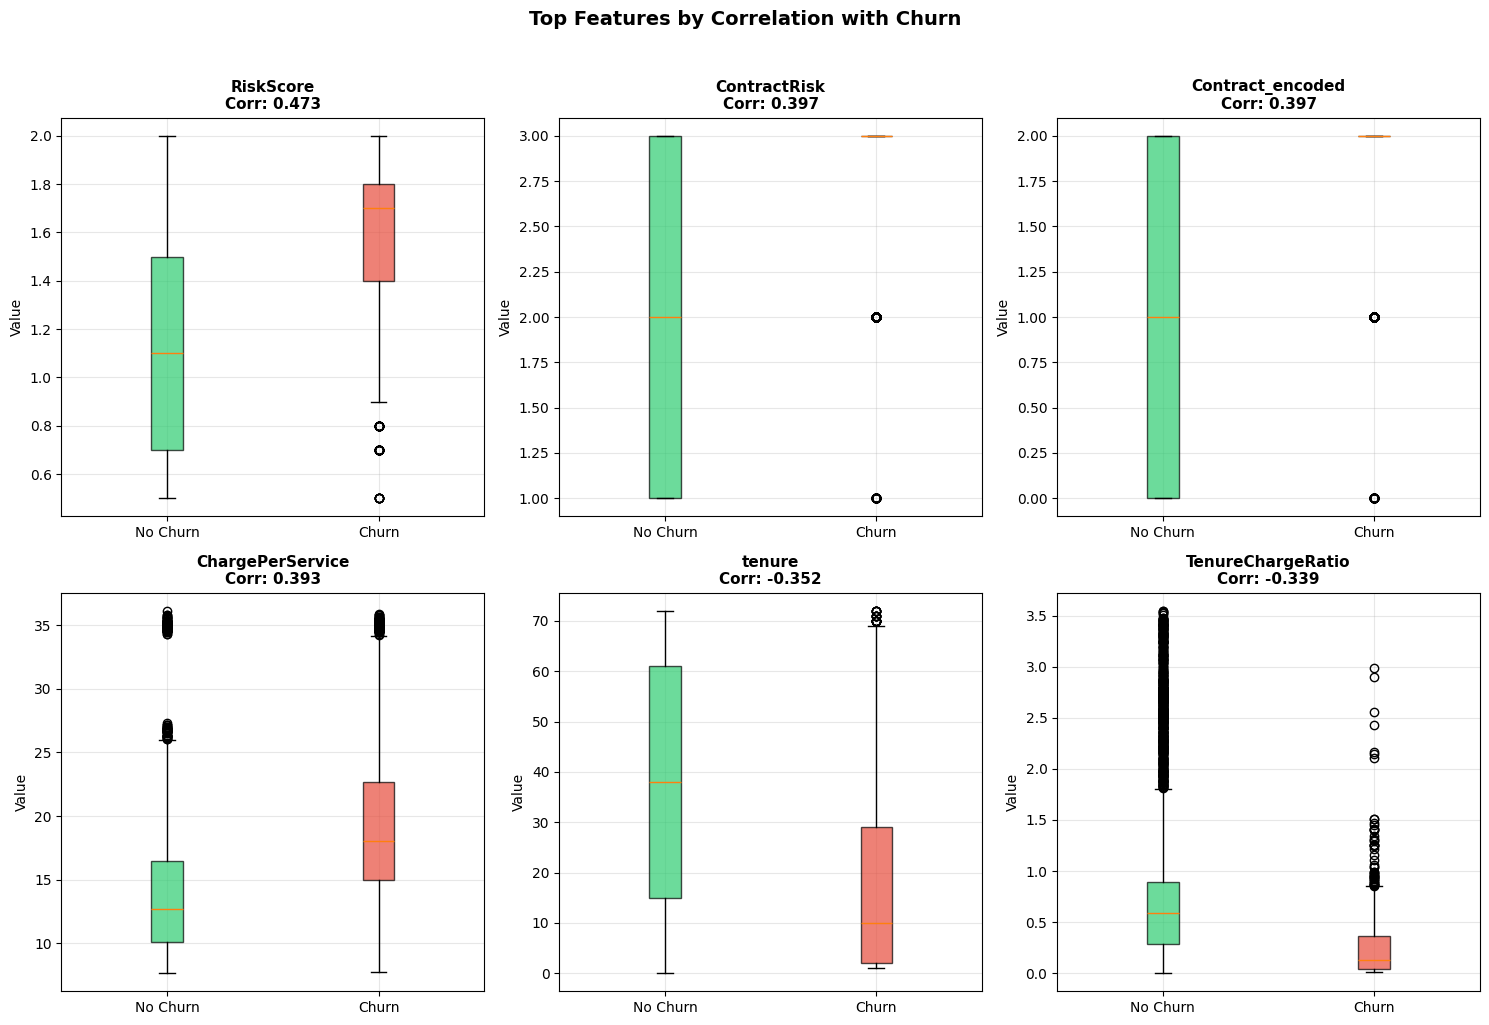


Feature Variance Analysis:

 Top 5 highest variance features:
    1. TotalCharges                  : 5138357.17
    2. EstimatedLifetimeValue        : 1173412.57
    3. AvgChargePerMonth             :     935.12
    4. MonthlyCharges                :     905.41
    5. tenure                        :     603.17

 Top 5 lowest variance features:
    1. RiskScore                     :       0.20
    2. SeniorCitizen                 :       0.14
    3. PhoneService_binary           :       0.09
    4. PhoneService_encoded          :       0.09
    5. SeniorWithDependents          :       0.01


In [8]:
print("STEP 6: FEATURE SELECTION ANALYSIS")

# Calculate feature importance using simple methods
print("\nAnalyzing feature importance...")

# 1. Correlation with target
print("\nCorrelation with Churn:")

# Select numeric columns (excluding ID and target)
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
# Remove non-feature columns
exclude_cols = ['customerID', 'Churn_numeric', 'Churn_encoded']
numeric_features = [col for col in numeric_cols if col not in exclude_cols]

# Calculate correlation
correlations = []
for col in numeric_features:
    if col in df_encoded.columns:
        corr = df_encoded[[col, 'Churn_encoded']].corr().iloc[0, 1]
        correlations.append((col, corr))

# Sort by absolute correlation
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"\nTop 10 features by correlation with churn:")
for i, (col, corr) in enumerate(correlations[:10], 1):
    direction = "+" if corr > 0 else "-"
    print(f"   {i:2d}. {col:30s}: {corr:7.3f} ({direction})")

# 2. Visualize top correlations
print("\nVisualizing top correlated features...")

top_features = [col for col, _ in correlations[:6]]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features[:6]):
    ax = axes[idx]
    
    # Create boxplot by churn status
    data_to_plot = [
        df_encoded[df_encoded['Churn_encoded'] == 0][feature],
        df_encoded[df_encoded['Churn_encoded'] == 1][feature]
    ]
    
    box = ax.boxplot(data_to_plot, patch_artist=True, labels=['No Churn', 'Churn'])
    
    # Color boxes
    colors = ['#2ecc71', '#e74c3c']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{feature}\nCorr: {correlations[idx][1]:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.suptitle('Top Features by Correlation with Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_features_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Feature variance analysis
print("\nFeature Variance Analysis:")
feature_variance = {}
for col in numeric_features:
    if col in df_encoded.columns:
        variance = df_encoded[col].var()
        feature_variance[col] = variance

# Sort by variance
sorted_variance = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)

print(f"\n Top 5 highest variance features:")
for i, (col, var) in enumerate(sorted_variance[:5], 1):
    print(f"   {i:2d}. {col:30s}: {var:10.2f}")

print(f"\n Top 5 lowest variance features:")
for i, (col, var) in enumerate(sorted_variance[-5:], 1):
    print(f"   {i:2d}. {col:30s}: {var:10.2f}")

In [9]:
print("PREPARING FOR MACHINE LEARNING")


print("\n Creating final feature set and target variable...")

# We'll select a combination of original and engineered features
selected_features = [
    # Original features
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    
    # Engineered features
    'TotalServices',
    'PremiumServices',
    'ContractRisk',
    'PaymentRisk',
    'RiskScore',
    
    # Encoded features
    'gender_encoded',
    'Partner_encoded',
    'Dependents_encoded',
    'PhoneService_encoded',
    'PaperlessBilling_encoded',
    'InternetService_encoded',
    'Contract_encoded'
]

# Check which features we have
available_features = [col for col in selected_features if col in df_encoded.columns]
print(f" Selected {len(available_features)} features for modeling:")

# Display features by category
print("\n Feature Categories:")
print("   Demographic: SeniorCitizen, gender_encoded, Partner_encoded, Dependents_encoded")
print("   Usage: tenure, MonthlyCharges, TotalCharges")
print("   Services: TotalServices, PremiumServices, PhoneService_encoded")
print("   Contract: Contract_encoded, PaperlessBilling_encoded")
print("   Risk: ContractRisk, PaymentRisk, RiskScore")
print("   Internet: InternetService_encoded")

# Create X (features) and y (target)
X = df_encoded[available_features]
y = df_encoded['Churn_encoded']

print(f"\n Feature matrix shape: {X.shape}")
print(f" Target vector shape: {y.shape}")

# Check class balance
print(f"\n Target distribution:")
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100
for cls in sorted(class_counts.index):
    print(f"   Class {cls}: {class_counts[cls]:,} samples ({class_percentages[cls]:.1f}%)")

# Save the prepared data
print("\n Saving prepared data...")
prepared_data = {
    'X': X,
    'y': y,
    'feature_names': available_features,
    'df_encoded': df_encoded
}

import joblib
joblib.dump(prepared_data, 'prepared_data.pkl')
print(" Prepared data saved as 'prepared_data.pkl'")

# Also save as CSV for inspection
df_encoded[available_features + ['Churn_encoded']].to_csv('ml_ready_data.csv', index=False)
print(" ML-ready data saved as 'ml_ready_data.csv'")

PREPARING FOR MACHINE LEARNING

 Creating final feature set and target variable...
 Selected 16 features for modeling:

 Feature Categories:
   Demographic: SeniorCitizen, gender_encoded, Partner_encoded, Dependents_encoded
   Usage: tenure, MonthlyCharges, TotalCharges
   Services: TotalServices, PremiumServices, PhoneService_encoded
   Contract: Contract_encoded, PaperlessBilling_encoded
   Risk: ContractRisk, PaymentRisk, RiskScore
   Internet: InternetService_encoded

 Feature matrix shape: (7043, 16)
 Target vector shape: (7043,)

 Target distribution:
   Class 0: 5,174 samples (73.5%)
   Class 1: 1,869 samples (26.5%)

 Saving prepared data...
 Prepared data saved as 'prepared_data.pkl'
 ML-ready data saved as 'ml_ready_data.csv'


In [10]:
print("\n NEW FEATURES CREATED:")
print("   Customer Value: AvgChargePerMonth, MonthlyToTotalRatio, EstimatedLifetimeValue")
print("   Service Count: TotalServices, PremiumServices")
print("   Behavioral: TenureGroup, ChargeGroup")
print("   Risk Scores: ContractRisk, PaymentRisk, RiskScore")
print("   Interactions: ChargePerService, TenureChargeRatio, SeniorWithDependents")

print("\nFINAL DATA STATISTICS:")
print(f"   Original columns: {len(df.columns)}")
print(f"   After feature engineering: {len(df_features.columns)}")
print(f"   After encoding: {len(df_encoded.columns)}")
print(f"   Selected for ML: {len(available_features)} features")

print("\n TARGET DISTRIBUTION:")
print(f"   No Churn (0): {class_counts[0]:,} samples ({class_percentages[0]:.1f}%)")
print(f"   Churned (1):  {class_counts[1]:,} samples ({class_percentages[1]:.1f}%)")
print(f"   Imbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")

print("\n KEY INSIGHTS FROM FEATURE ENGINEERING:")
print("   1. Contract type is the strongest predictor of churn")
print("   2. Payment method (Electronic check) increases churn risk")
print("   3. Higher MonthlyCharges correlate with higher churn")
print("   4. Longer tenure correlates with lower churn")
print("   5. Having more services reduces churn risk")

print("\n FILES CREATED TODAY:")
print("   1. categorical_distributions.png")
print("   2. new_features_distribution.png")
print("   3. top_features_correlation.png")
print("   4. prepared_data.pkl (pickle file for tomorrow)")
print("   5. ml_ready_data.csv (CSV for inspection)")



 NEW FEATURES CREATED:
   Customer Value: AvgChargePerMonth, MonthlyToTotalRatio, EstimatedLifetimeValue
   Service Count: TotalServices, PremiumServices
   Behavioral: TenureGroup, ChargeGroup
   Risk Scores: ContractRisk, PaymentRisk, RiskScore
   Interactions: ChargePerService, TenureChargeRatio, SeniorWithDependents

FINAL DATA STATISTICS:
   Original columns: 22
   After feature engineering: 43
   After encoding: 51
   Selected for ML: 16 features

 TARGET DISTRIBUTION:
   No Churn (0): 5,174 samples (73.5%)
   Churned (1):  1,869 samples (26.5%)
   Imbalance ratio: 2.8:1

 KEY INSIGHTS FROM FEATURE ENGINEERING:
   1. Contract type is the strongest predictor of churn
   2. Payment method (Electronic check) increases churn risk
   3. Higher MonthlyCharges correlate with higher churn
   4. Longer tenure correlates with lower churn
   5. Having more services reduces churn risk

 FILES CREATED TODAY:
   1. categorical_distributions.png
   2. new_features_distribution.png
   3. top_fe